In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('7817_1.csv')

print(f"Dataset Shape: {df.shape}")

print("\n--- Missing Values ---")
print(df[['reviews.text', 'reviews.rating']].isnull().sum())

print(f"\nDuplicate review texts: {df.duplicated(subset=['reviews.text']).sum()}")


df[['reviews.text', 'reviews.rating']].head()

print(df.dtypes)

Dataset Shape: (1597, 27)

--- Missing Values ---
reviews.text        0
reviews.rating    420
dtype: int64

Duplicate review texts: 549
id                          str
asins                       str
brand                       str
categories                  str
colors                      str
dateAdded                   str
dateUpdated                 str
dimension                   str
ean                     float64
keys                        str
manufacturer                str
manufacturerNumber          str
name                        str
prices                      str
reviews.date                str
reviews.doRecommend      object
reviews.numHelpful      float64
reviews.rating          float64
reviews.sourceURLs          str
reviews.text                str
reviews.title               str
reviews.userCity        float64
reviews.userProvince    float64
reviews.username            str
sizes                   float64
upc                     float64
weight                      str


### Figure 1: Distribution of Target Labels (Ratings)

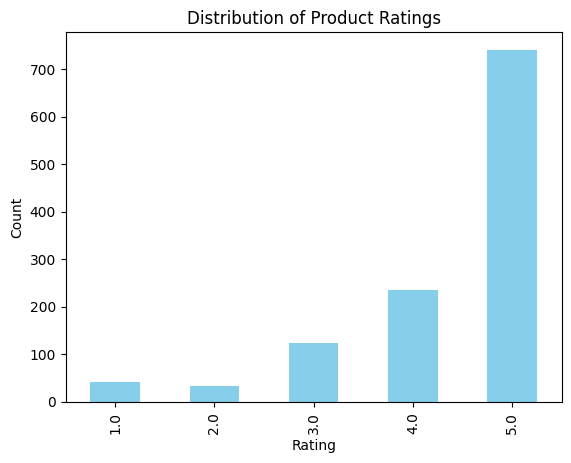

In [13]:
df['reviews.rating'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

### Figure 2: Distribution of Review Character Lengths

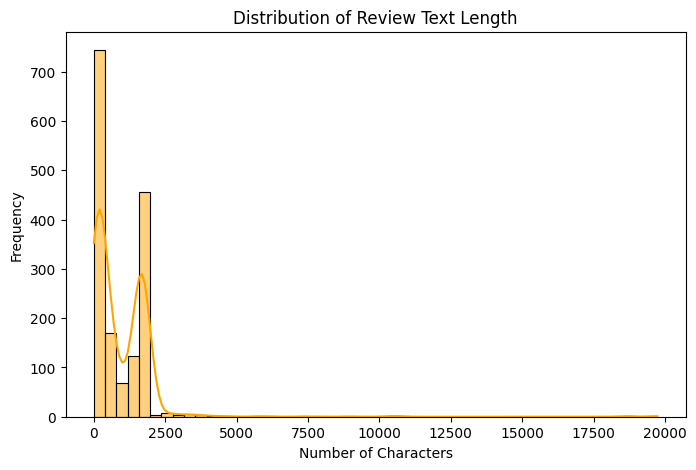

In [14]:
df['text_length'] = df['reviews.text'].astype(str).apply(len)

plt.figure(figsize=(8, 5))
sns.histplot(df['text_length'], bins=50, color='orange', kde=True)
plt.title('Distribution of Review Text Length')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()  

### Figure 3: Review Length across Different Ratings (Box Plot)

C:\Users\Jenny Rodriguez\AppData\Local\Temp\ipykernel_22048\3420098046.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='reviews.rating', y='text_length', data=df, palette='Set2')


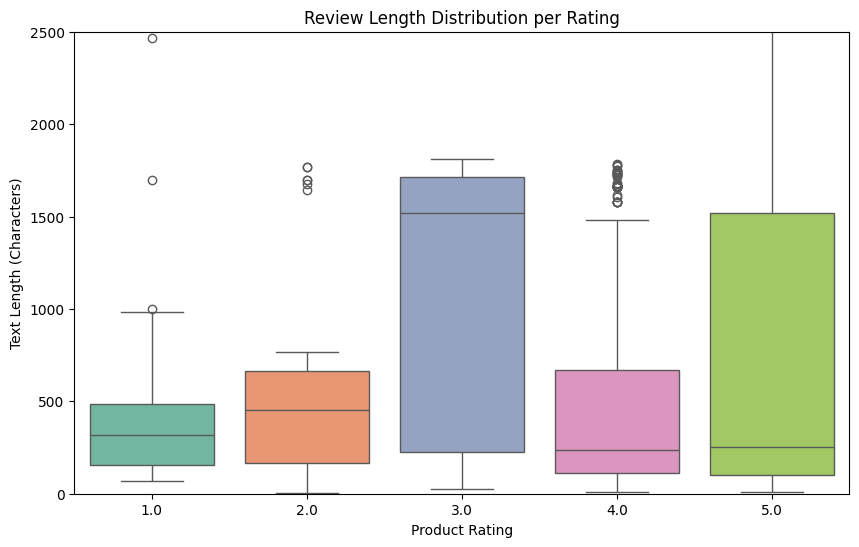

In [15]:
# New Cell: Visualizing Text Length by Rating
plt.figure(figsize=(10, 6))
sns.boxplot(x='reviews.rating', y='text_length', data=df, palette='Set2')
plt.title('Review Length Distribution per Rating')
plt.xlabel('Product Rating')
plt.ylabel('Text Length (Characters)')
plt.ylim(0, 2500) # Clipping outliers to make the boxes clearer
plt.show()

### Figure 4: Correlation Heatmap of Numerical Metadata

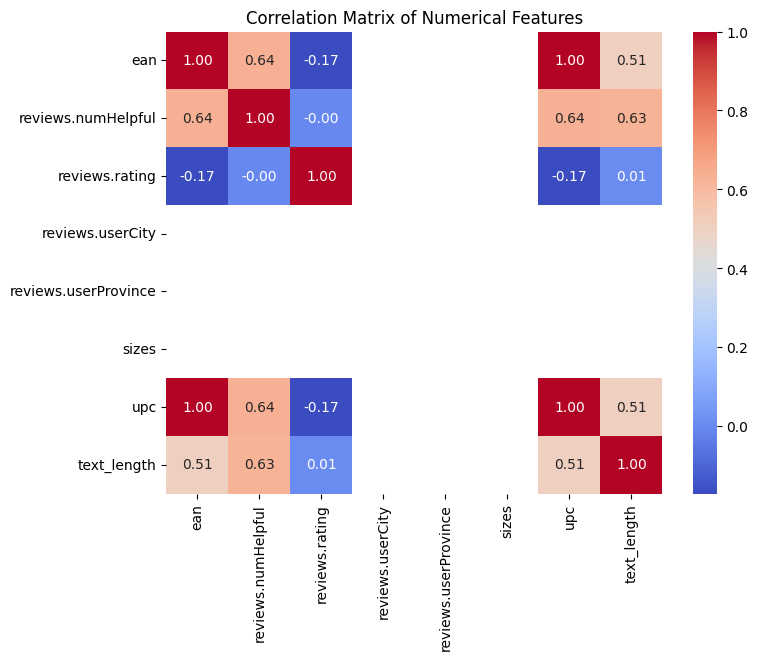

In [16]:
# New Cell: Correlation Heatmap
plt.figure(figsize=(8, 6))
# Selecting only numerical columns for correlation
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Figure 5: Top 5 Most Reviewed Products

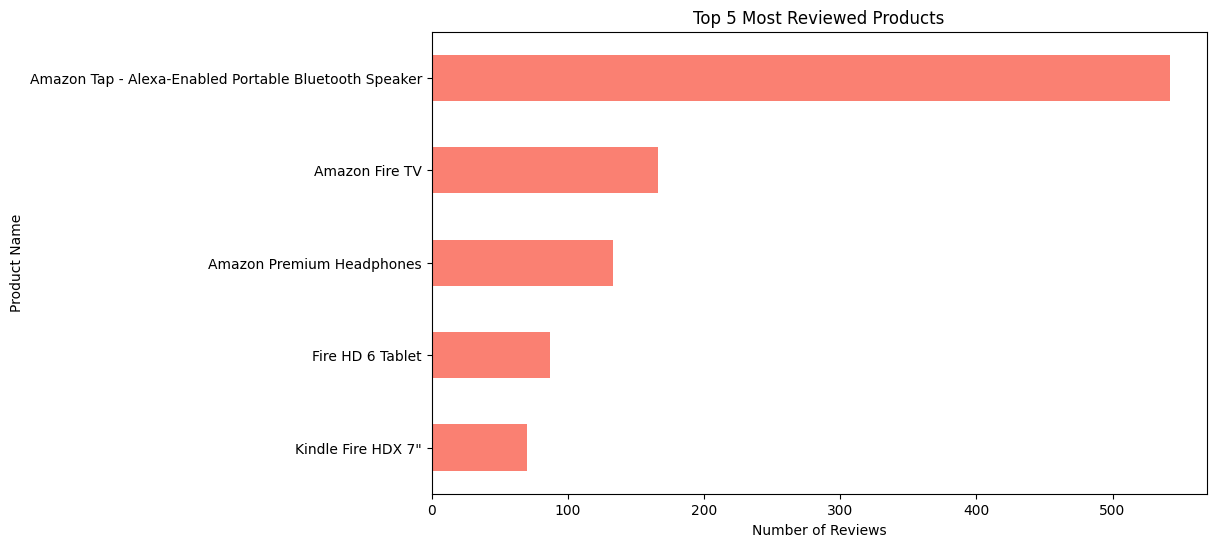

In [17]:
# New Cell: Top 5 Most Reviewed Products
plt.figure(figsize=(10, 6))
df['name'].value_counts().head(5).plot(kind='barh', color='salmon')
plt.title('Top 5 Most Reviewed Products')
plt.xlabel('Number of Reviews')
plt.ylabel('Product Name')
plt.gca().invert_yaxis() # Highest on top
plt.show()

# Sentiment Skew (Chart 1) #

The data is imbalanced, dominated by 5-star ratings, which may require "over-sampling" or "under-sampling" during the training phase.

# Text Variability (Chart 2 & 3) #

Most reviews are short (under 500 characters), but the box plot shows that lower ratings (1-2 stars) often have slightly more variance in length, meaning unhappy customers sometimes write very detailed complaints.

# Low Feature Correlation (Chart 4) #

The heatmap reveals a low correlation between reviews.numHelpful and reviews.rating, suggesting that "helpful" reviews aren't necessarily tied to high or low scores.

# Product Dominance (Chart 5) #

A few products, like the Kindle Paperwhite, dominate the dataset. This is important because the model might learn product-specific keywords instead of general sentiment if we aren't careful.